In [1]:
# For matrix support
import tinyarray
import kwant

In [13]:
# define Pauli-matrices for convenience
sigma_0 = tinyarray.array([[1, 0], [0, 1]])
sigma_x = tinyarray.array([[0, 1], [1, 0]])
sigma_y = tinyarray.array([[0, -1j], [1j, 0]])
sigma_z = tinyarray.array([[1, 0], [0, -1]])
t = 1.0
alpha = 1.0
e_z = 0.08
W, L = 10, 30
syst = kwant.Builder()
lat = kwant.lattice.square(norbs=2)
#### Define the scattering region. ####
syst[(lat(x, y) for x in range(L) for y in range(W))] = \
    4 * t * sigma_0 + e_z * sigma_z
# hoppings in x-direction
syst[kwant.builder.HoppingKind((1, 0), lat, lat)] = \
    -t * sigma_0 + 1j * alpha * sigma_y / 2
# hoppings in y-directions
syst[kwant.builder.HoppingKind((0, 1), lat, lat)] = \
    -t * sigma_0 - 1j * alpha * sigma_x / 2

In [14]:
# define lead
lead = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))

# lead sites
lead[(lat(0, j) for j in range(W))] = \
    4 * t * sigma_0 + e_z * sigma_z

# hoppings in x-direction (along transport)
lead[kwant.builder.HoppingKind((1, 0), lat, lat)] = \
    -t * sigma_0 + 1j * alpha * sigma_y / 2

# hoppings in y-direction
lead[kwant.builder.HoppingKind((0, 1), lat, lat)] = \
    -t * sigma_0 - 1j * alpha * sigma_x / 2

# attach leads
syst.attach_lead(lead)
syst.attach_lead(lead.reversed())

[]

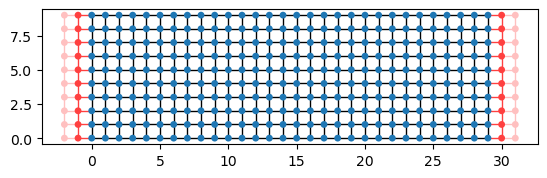

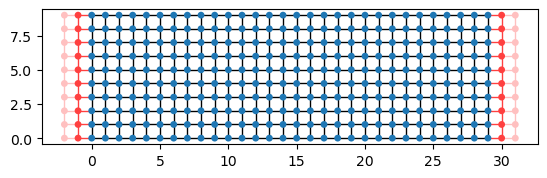

In [16]:
kwant.plot(syst)

G(E=0) = 1.9999999999999984


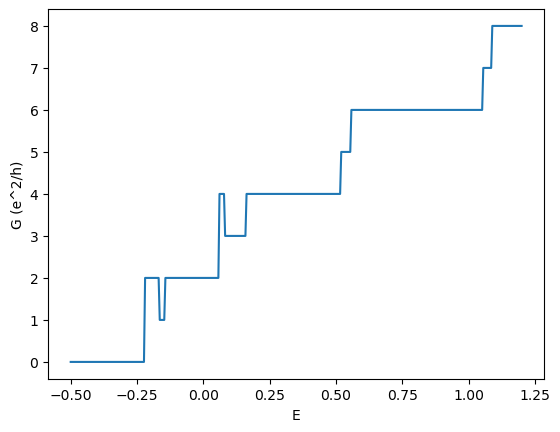

In [15]:
import kwant
import numpy as np
import matplotlib.pyplot as plt

# ===== finalized system =====
fsyst = syst.finalized()

# ===== 单一能量的电导 =====
E = 0.0
smat = kwant.smatrix(fsyst, energy=E)
G0 = smat.transmission(1, 0)
print("G(E=0) =", G0)

# ===== 能量扫描 =====
energies = np.linspace(-0.5, 1.2, 401)
G = []

for E in energies:
    smat = kwant.smatrix(fsyst, energy=E)
    G.append(smat.transmission(1, 0))

# ===== 画图 =====
plt.figure()
plt.plot(energies, G)
plt.xlabel("E")
plt.ylabel("G (e^2/h)")
plt.show()


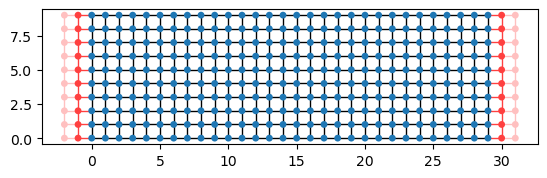

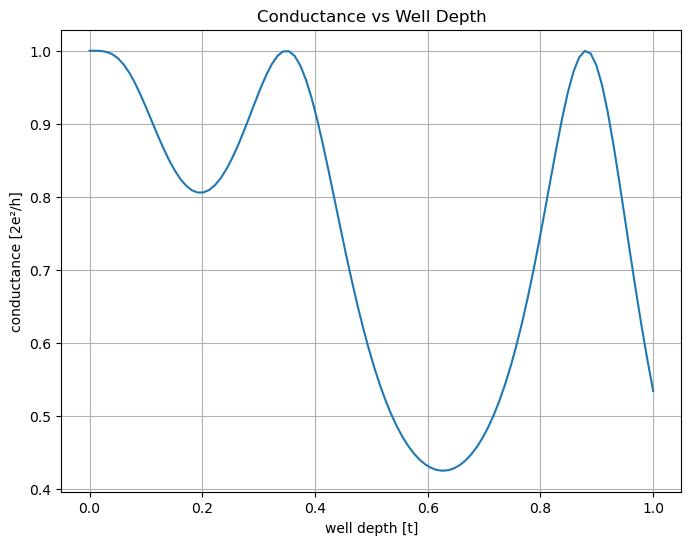

In [27]:
import kwant
import numpy as np
import matplotlib.pyplot as plt  # 必须导入 plt（教程里用了 pyplot，但标准是 plt）

W, L, L_well = 10, 30, 10

def potential(site, pot):
    (x, y) = site.pos
    if (L - L_well) / 2 < x < (L + L_well) / 2:
        return pot
    else:
        return 0

a = 1
t = 1.0

def onsite(site, pot):
    return 4 * t + potential(site, pot)

# 格子 + 系统
lat = kwant.lattice.square(a, norbs=1)
syst = kwant.Builder()

# 散射区
syst[(lat(x, y) for x in range(L) for y in range(W))] = onsite

# 跳跃
syst[lat.neighbors()] = -t

# 引线（教程默认简单引线，这里手动加）
sym_left = kwant.TranslationalSymmetry((-a, 0))
left_lead = kwant.Builder(sym_left)
for j in range(W):
    left_lead[lat(0, j)] = 4 * t  # 引线无阱
    if j > 0:
        left_lead[lat(0, j), lat(0, j-1)] = -t
    left_lead[lat(1, j), lat(0, j)] = -t

syst.attach_lead(left_lead)
syst.attach_lead(left_lead.reversed())

syst = syst.finalized()
kwant.plot(syst)
# 画电导 vs 阱深度
def plot_conductance(syst, energy, welldepths):
    data = []
    for welldepth in welldepths:
        smatrix = kwant.smatrix(syst, energy, params=dict(pot=-welldepth))
        data.append(smatrix.transmission(1, 0))
    
    plt.figure(figsize=(8, 6))
    plt.plot(welldepths, data)
    plt.xlabel("well depth [t]")
    plt.ylabel("conductance [2e²/h]")
    plt.title("Conductance vs Well Depth")
    plt.grid(True)
    plt.show()

# 调用函数
energy = 0.2  # 固定能量
welldepths = np.linspace(0, 1, 100)  # 阱深度从 0 到 -5t
plot_conductance(syst, energy, welldepths)